In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("WATSONX_API_KEY")
IBM_QUANTUM_INSTANCE = os.getenv("IBM_QUANTUM_INSTANCE")


In [2]:

from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
  token=f"{API_KEY}",
  instance=f"{IBM_QUANTUM_INSTANCE}",
  overwrite=True
)


x-gate vector
operation연산 브라-켓

0 -> 1
1 -> 0

Phi-plus ??

고전반가산기 
양자회로는 가역적

하드웨어에 존재하는 잡음
잡음을 얼마나 잡느냐 - 퀀텀 기술 중 하나

Qiskit 패턴: 
매핑: 게이트 만드는 것
 -> 
최적화: 실제 하드웨어에서 실행 가능하도록 회로 최적화 / 논리적인 큐비트를 물리적 큐비트에 저장
 -> 
실행
 -> 
후처리

시뮬레이터에서 테스트

큐피트 | 의미
|---|---|
0 | 입력 A
1 | 입력 B
2 | 합 S = A xor B
3 | 자리올림 C = A·B

In [ ]:
%pip install matplotlib
%pip install pylatexenc

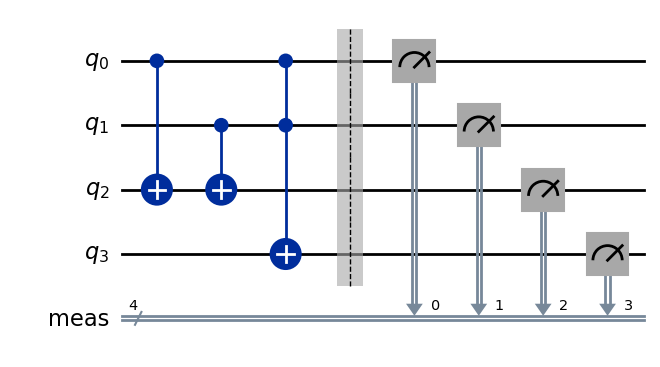

In [1]:

from qiskit import QuantumCircuit


# 큐비트: a,b,합(sum),자리올림(carry)
qc = QuantumCircuit(4)

# A와 B에 넣을 값 / 2개에 큐비트
a=0
b=0

# 선택한 값에 따라 A,B 큐피트를 준비
if a:
  qc.x(0)
if b:
  qc.x(1)

# XOR(합)을 큐피트 2에 계산
qc.cx(0,2)
qc.cx(1,2)

# AND(자리올림)를 큐피트 3에 계산
qc.ccx(0,1,3) # a AND b

# 측정
qc.measure_all()

qc.draw('mpl')

In [2]:
from qiskit import generate_preset_pass_manager

# 인증정보 불러오기
service = QiskitRuntimeService()

# least_busy 한가한 컴퓨터에 배치
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# print(backend.name)


ibm_marrakesh


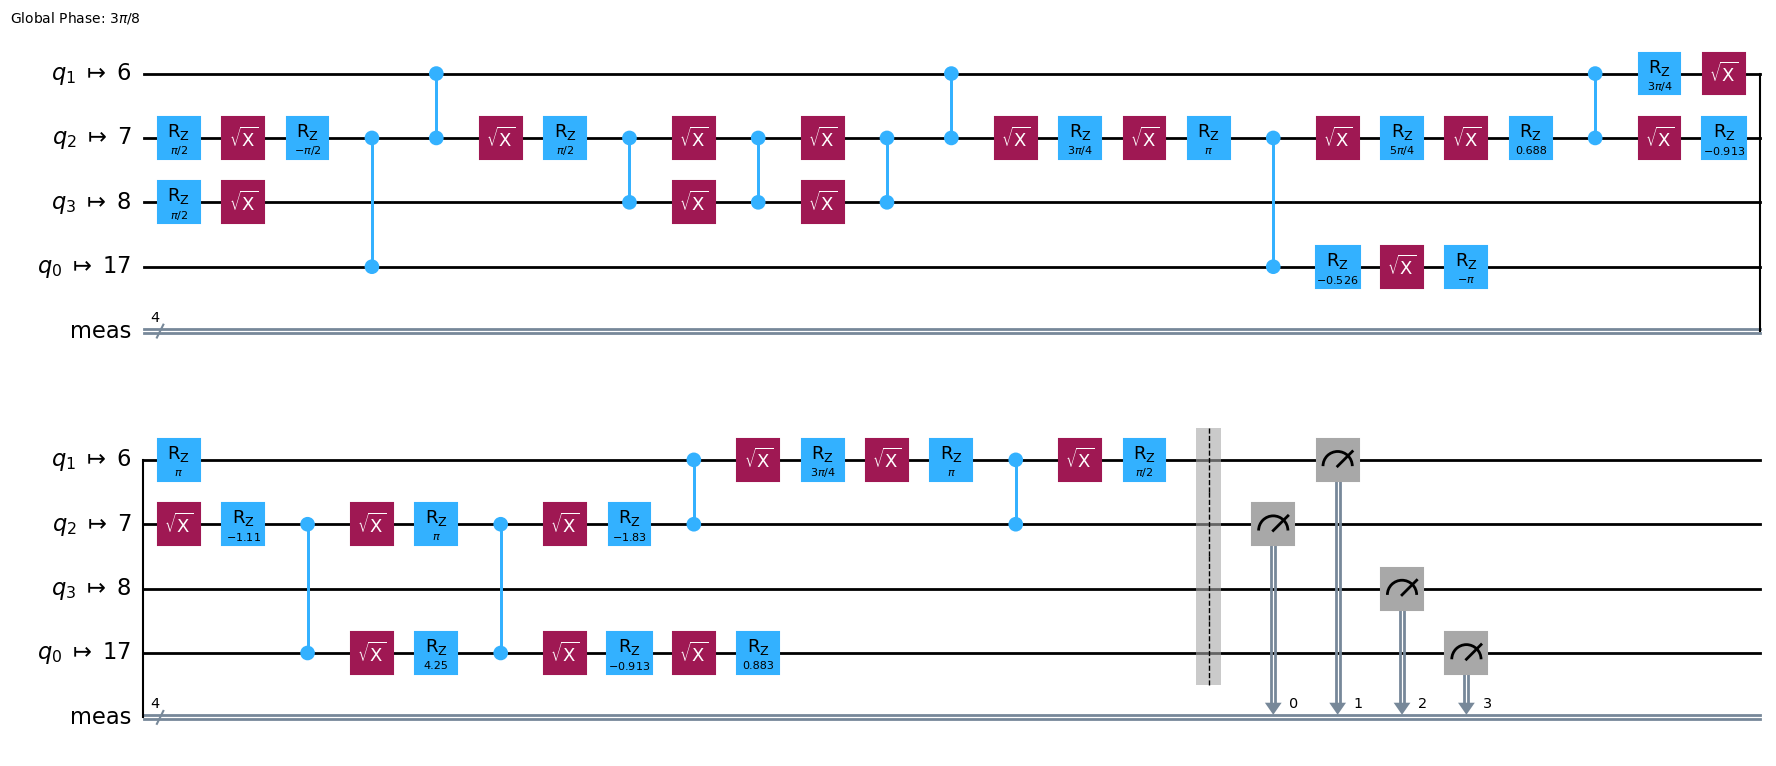

In [5]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# transpiler
# 3: 가장 강한 최적화
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

# qiskit이 해준다.

In [ ]:
# sampler
# 양자 회로를 실행했을 때 나올 수 있는 상태들의 표본을 추출하고, 각 상태가 어떤 확률로 측정되는지 통계를 모아주는 Qiskit의 프리미티브 입니다.
# 여러번 실행해서 측정 결과의 분포를 확인

from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)


In [12]:
job = sampler.run([qc_isa], shots=100)
res = job.result()
counts = res[0].data.meas.get_counts()

/Users/sunahgwak/Documents/Repository/source/quantum/.venv/lib/python3.12/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1013: UserWarning: The backend ibm_marrakesh currently has a status of maintenance.
  warnings.warn(


In [17]:
# 시뮬레이터 사용
# 실제 백엔드의 노이즈 특성을 바탕으로 시뮬레이터를 만드는 예시

from qiskit.primitives import BackendSamplerV2
# Aer 시뮬레이터를 불러오고, 현재 선틱된 백엔드를 바탕으로 노이즈 모델 생성

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend=backend)

# Aer로 시뮬레이터를 정의하고 이를 Sampler에 사용
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)



In [18]:
job = sampler_sim.run([qc_isa])
res = job.result()
counts = res[0].data.meas.get_counts()

counts= {'1000': 18, '0000': 970, '0100': 10, '0001': 10, '0010': 6, '0110': 1, '1001': 4, '0011': 1, '1100': 3, '1010': 1}


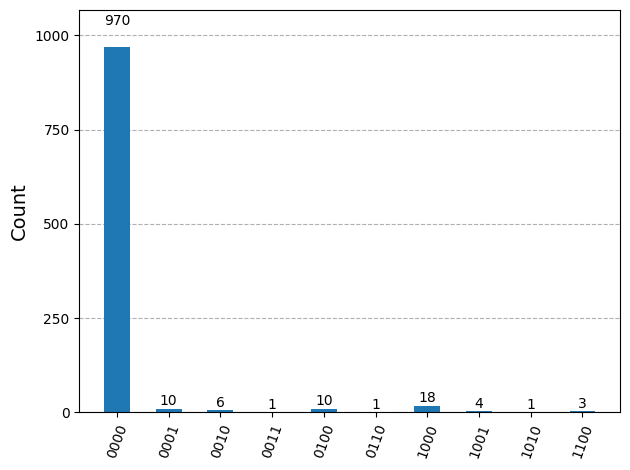

In [19]:
# 후처리 
# a,b 1로 바꿔서 확인해보기

from qiskit.visualization import plot_histogram
print("counts=", counts)
plot_histogram(counts)

- 큐비트는 0과 1의 중첩 상태
- 중첩이 얽힌 것 비트로 환산
- 양자 게이트는 가역적 
- 회로는 왼쪽에서 오른쪽으로 읽기

양자컴퓨터... 소프트웨어 역할이 키스킷 
benchpress 성능비교 라이브러리
